# (25) deep dec — cifar10

**Motivation**: host = ```yoru```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('CIFAR10', model_type, 'ngd|deep')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 2/8 * t_train

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 4

cfg_tr['batch_size'] = 100
cfg_tr['epochs'] = 40

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

40000

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  1.2 Mil   |
|     ———     |    ———     |
|    layer    |  1.2 Mil   |
+-------------+------------+

poisson_CIFAR10_t-8_b-2_kms-(256,4,1)_<ngd|deep>
b100-ep40-lr(0.002)_temp(0.05)_gr(500)_(2025_07_25,13:39)

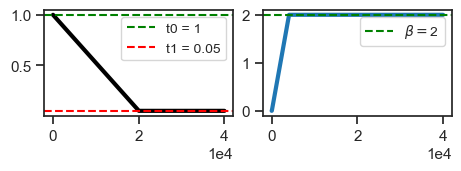

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10], device='cuda:0', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}") # \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(256, 4, 4), input_sz=(3, 32, 32), temp=1)

In [8]:
tr.model.layer.u_init[0].shape, tr.model.layer.log_bias.shape

(torch.Size([1, 256, 1, 1]), torch.Size([1, 256, 1, 1]))

In [9]:
tr.train()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 40, avg loss: 157.409: 100%|█████████| 40/40 [3:31:08<00:00, 316.70s/it]


100%|███████████████████████████████████| 5/5 [01:00<00:00, 12.19s/it]


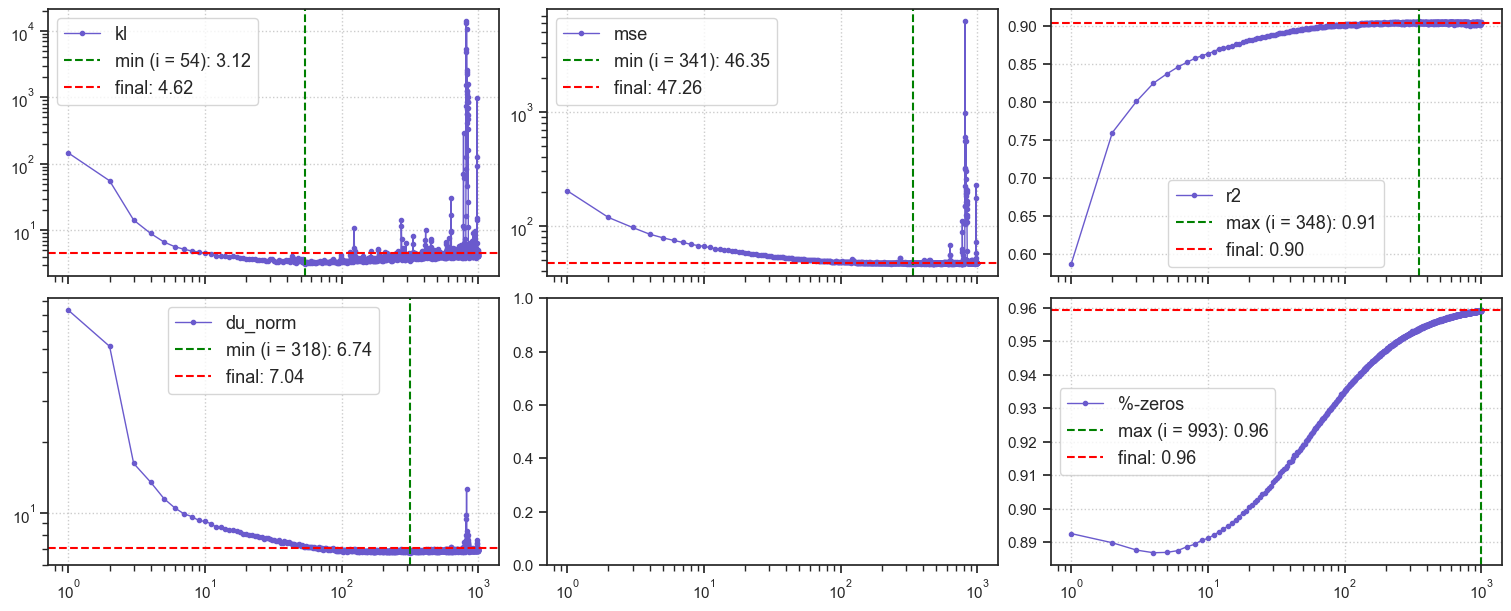

CPU times: user 1min 7s, sys: 2.51 s, total: 1min 10s
Wall time: 1min 10s


In [13]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='slateblue')

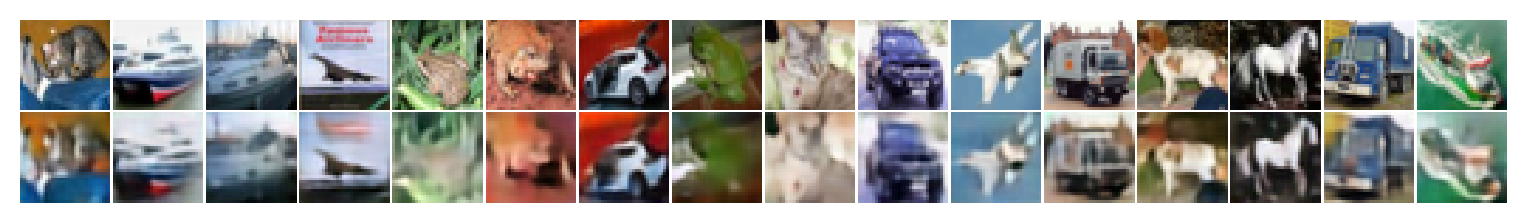

In [15]:
tr.show_recon();

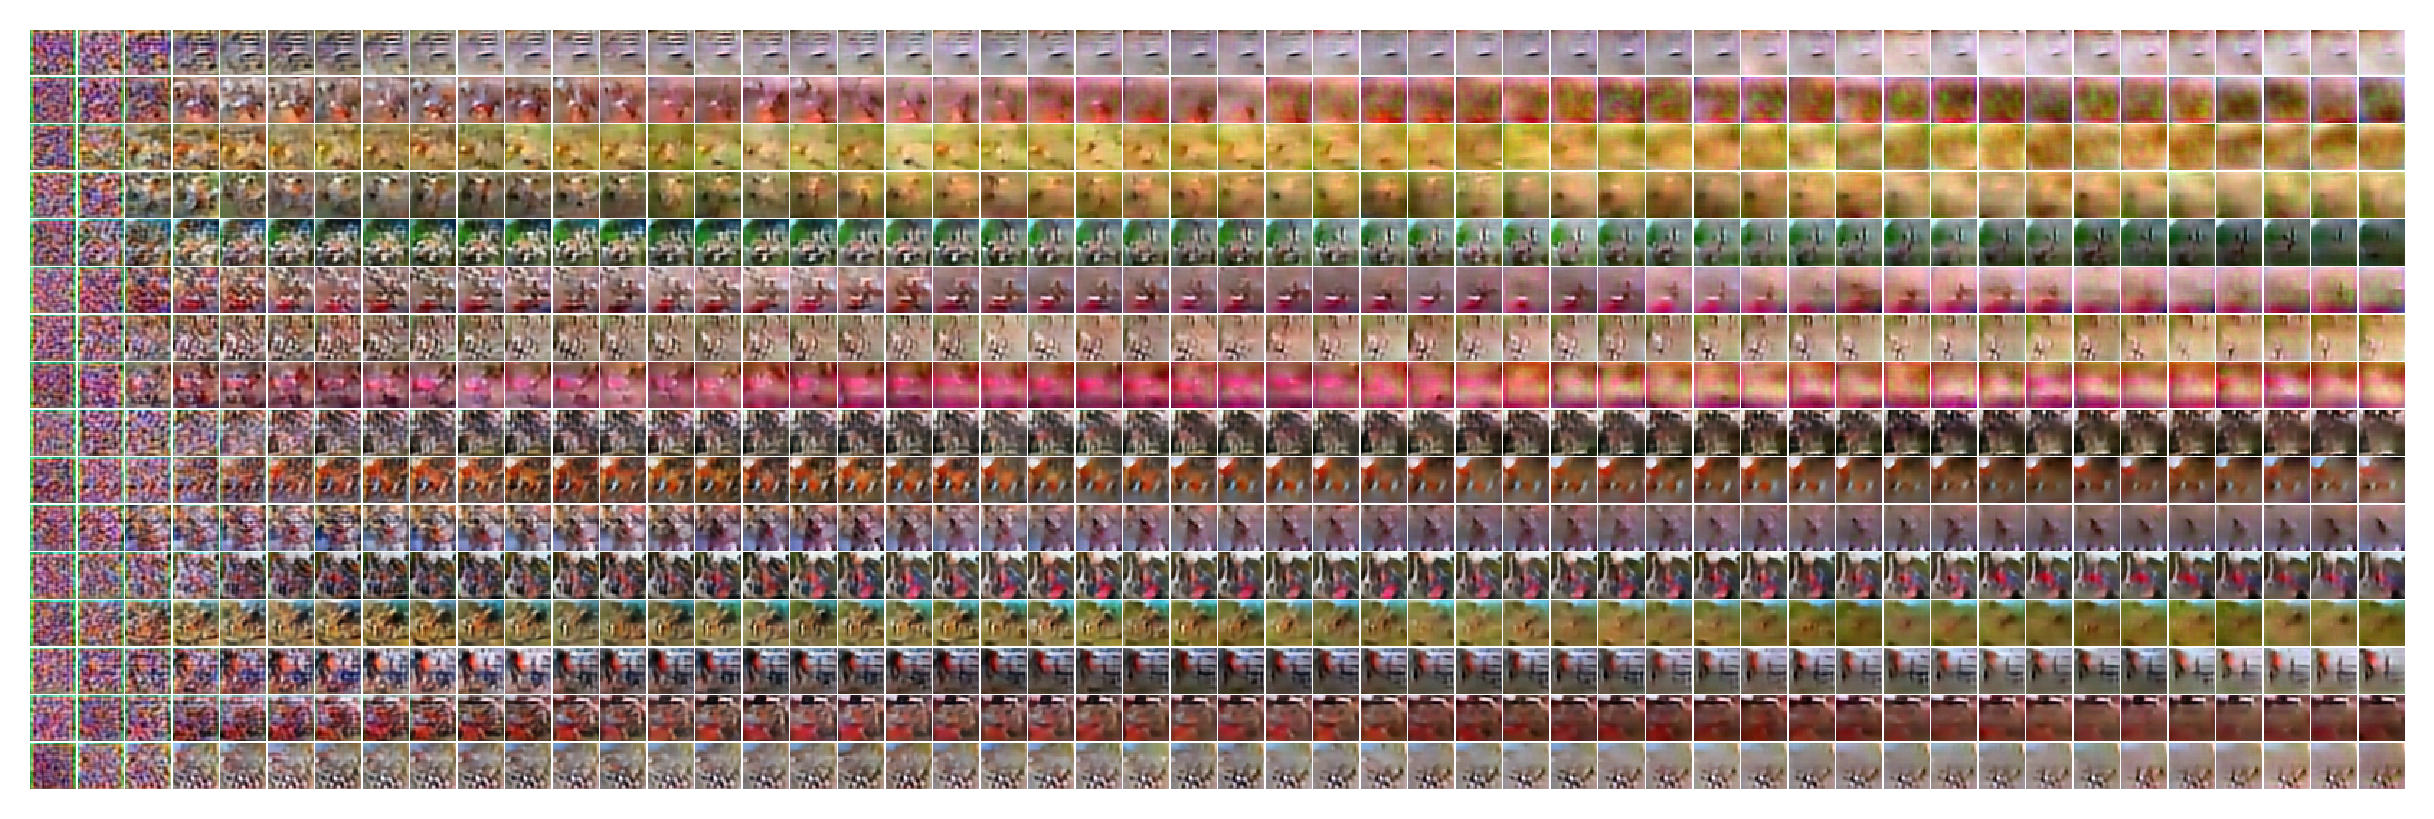

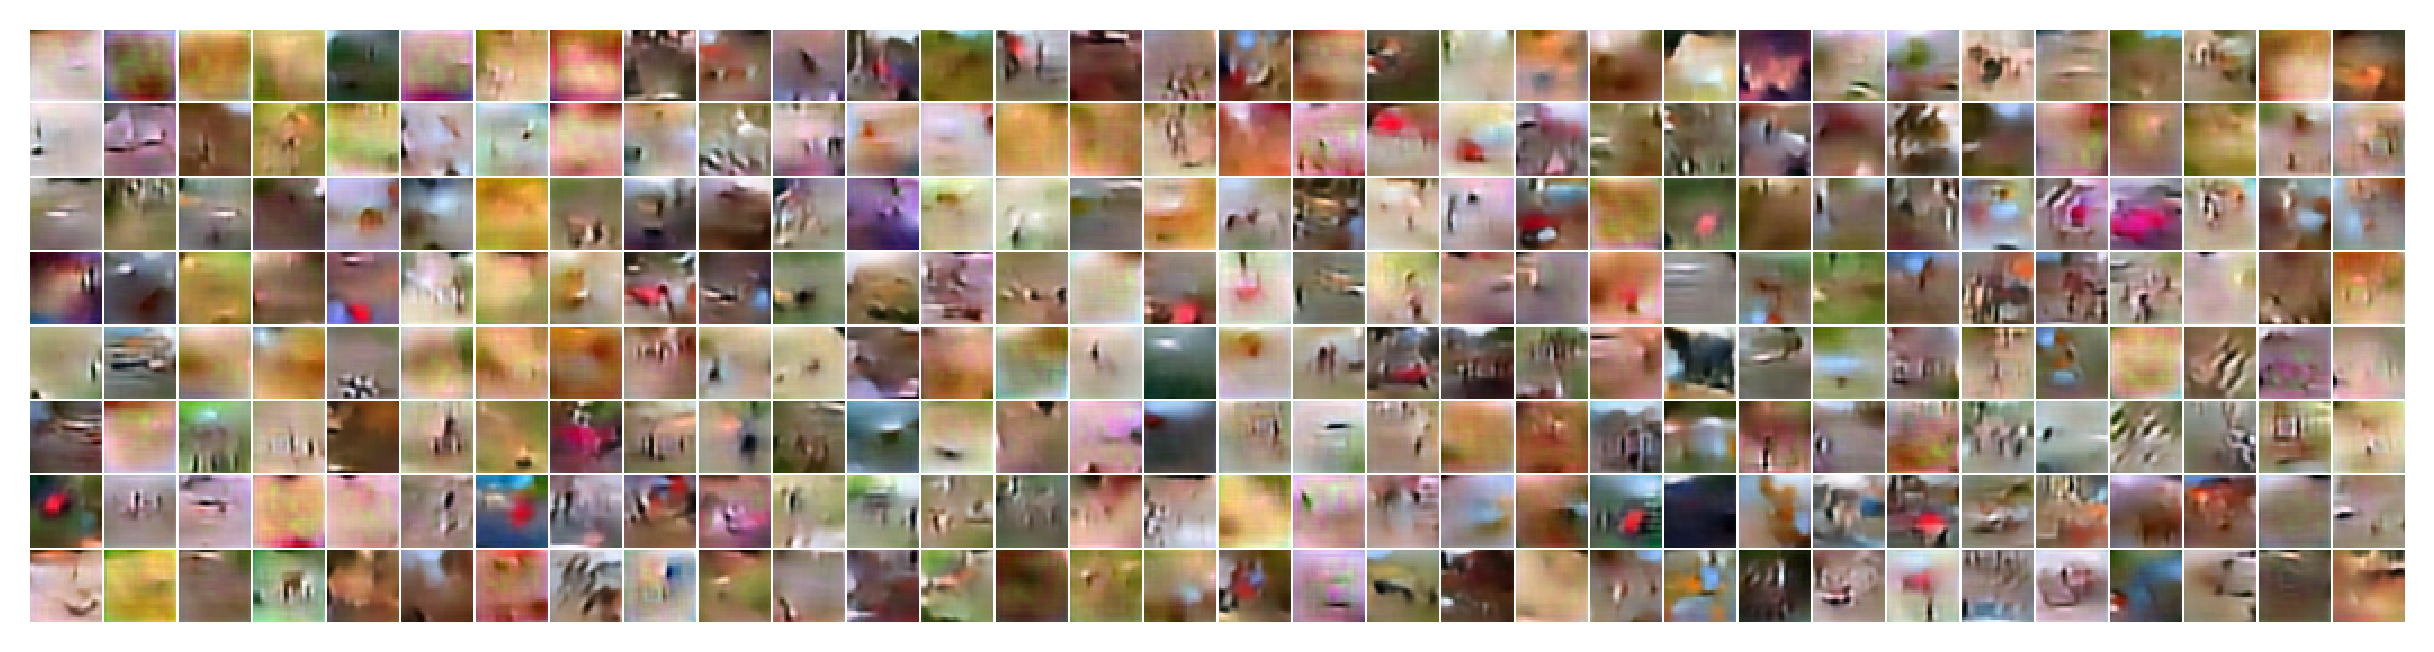

In [16]:
tr.show_samples();

In [17]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)
bias.shape

(256,)

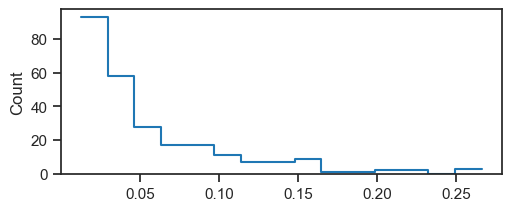

In [18]:
fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

In [19]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u0.shape

(256,)

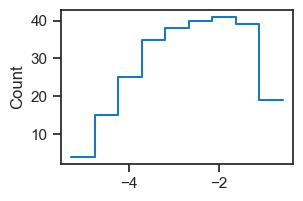

In [20]:
histplot(u0.ravel())
plt.show()

In [21]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.9167732558144359, pvalue=3.1360683818746354e-103)

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']